In [53]:
import pandas as pd 
import numpy as np
df = pd.read_csv('Data set for DADS June.csv')

In [54]:
def parse_date_time(df):
    df ['Date'] = pd.to_datetime(df['Date'],errors='coerce',dayfirst=True)
    df ['hour'] = df['Time'].str.split(':').str[0].astype(int)
    df ['month']=df['Date'].dt.month
    df['day_of_week']=df['Date'].dt.dayofweek
    df['week_number'] = df['Date'].dt.isocalendar().week
    return df

In [55]:
def clean_amount(df):
    df["Amount"] = (
        df["Amount"]
        .astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("Rs.", "", regex=False)
        .str.strip()
    )

    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
    return df

In [56]:
def standardized_transaction_type(df):
    df['Type'] = df['Type'].str.strip().str.lower()  #ith ella 
    types ={
        "dr":"debit",
        "cr":"credit",
        "debit":"debit" 
        }
    df['Type'] = df['Type'].map(types)
    return df

In [57]:
def fdrop_duplicates(df):
    df = df.dropna(subset=['Date', 'Time', 'Amount', 'Type'])
    df= df.drop_duplicates()
    return df

In [58]:
def mode(df):
    df["Mode"]==df["Mode"].astype(str).str.strip()
    df["Mode"]=df["Mode"].replace("", np.nan)
    return df 

In [59]:
def first_parser(df):
    df = parse_date_time(df)
    df = clean_amount(df)
    df = standardized_transaction_type(df)
    df = fdrop_duplicates(df)
    df = mode(df)
    return df

In [60]:
df=first_parser(df)


In [61]:
print (df) 


           Date   Time             Description   Type  Amount   Balance Mode  \
0    2024-01-01  03:11      AMAZON SELLER SVCS  debit  2462.0  678275.0  UPI   
3    2024-01-01  14:07    UPI-AMAN-8934@OKAXIS  debit  1828.0 -748745.0  UPI   
5    2024-01-01  14:48              BHIM ZEPTO  debit   625.0  677650.0  UPI   
6    2024-01-01  14:50  UPI-UBER-2426@HDFCBANK  debit   148.0  677020.0  UPI   
8    2024-02-01  05:18    POS SWIGGY BANGALORE  debit   537.0  676177.0  UPI   
...         ...    ...                     ...    ...     ...       ...  ...   
1189 2024-11-06  14:25        ATM-WDL-SBI-4084  debit   500.0 -760375.0  ATM   
1193 2024-12-06  09:29      ATM-WDL-ICICI-4739  debit   500.0 -718445.0  ATM   
1194 2024-12-06  09:59        ZOMATO MEDIA P L  debit   383.0 -235104.0  UPI   
1195 2024-12-06  14:38   POS SWIGGY-RESTAURANT  debit   368.0 -234344.0  UPI   
1197 2024-12-06  16:29              POS ZOMATO  debit   377.0 -234721.0  UPI   

            Ref  hour  month  day_of_we

In [62]:
print(df["Description"].unique()) #to identify unique patterns in the description column.

<StringArray>
[              'AMAZON SELLER SVCS',             'UPI-AMAN-8934@OKAXIS',
                       'BHIM ZEPTO',           'UPI-UBER-2426@HDFCBANK',
             'POS SWIGGY BANGALORE',                 'ANI Technologies',
            'POS SWIGGY-RESTAURANT',               'POS UBER BANGALORE',
                        'TWC INDIA',               'UPI-STARBUCKS@AXIS',
                      'POS BLINKIT',                 'ZOMATO MEDIA P L',
                      'BHIM SWIGGY',                         'OLA CABS',
                 'UPI-DMART@OKAXIS',              'POS ZEPTO BANGALORE',
              'UPI-MYNTRA@HDFCBANK',            'BANGALORE ELEC SUPPLY',
                 'Amazon Pay India',            'UPI-PRIYA-2221@OKAXIS',
              'INSTAMART BANGALORE',         'UPI-ZOMATO-LIMITED@PAYTM',
         'UPI-SWIGGY-7959@HDFCBANK',      'UPI-SWIGGY-INSTAMART@OKAXIS',
                    'POS OLA-PRIME',            'POS EMPIRE RESTAURANT',
                 'SWIGGY-INSTAMART', 

In [63]:
import re 
#used AI to identify patterns in the description column and map them to vendors.
vendors = {
    r'INSTAMART': 'SWIGGY INSTAMART',  
    r'SWIGGY': 'SWIGGY',
    r'ZEPTO': 'ZEPTO',
    r'KIRANAKART': 'KIRANAKART',                      
    r'ZOMATO': 'ZOMATO',
    r'BLINKIT': 'BLINKIT',
    r'GROFERS': 'GROFERS',     # Old Blinkit name
    r'BUNDL': 'BUNDL',      # Swiggy parent company

    r'DMART': 'DMART',
    r'AVENUE SUPER': 'AVN',                   
    r'INNOVATIVE RETAIL': 'INNOVATIVE ', 
    r'BIGBASKET': 'BIGBASKET',              
    r'MYNTRA': 'MYNTRA',
    r'AMAZON': 'AMAZON',
    r'AMAZON PAY': 'PAY',
    r'AMAZONIN MARKETPLACE': 'AMAZON_MARKET',
    r'AMAZON SELLER': 'AMAZON SELLER',
    r'FSN E-COMMERCE': 'FSN',
    r'FLIPKART': 'FLIPKART',
    r'NYKAA': 'NYKAA',
    r'OLA ':'OLA',
    r'ANI TECH': 'OLA CABS',                         
    r'RAPIDO':'RAPIDO',
    r'ROPPEN': 'RAPO',
    r'AMZN': 'AMZN', 
    r'NETFLIX': 'NETFLIX',                       
    r'UBER': 'UBER',
    r'GROWWPAY': 'GROWW',
    r'BMTC': 'BMTC BUS TRANSIT', 
    r'TUMMOC': 'BMTC BUS TRANSIT',                       
    r'THIRDWAVE':'THIRD WAVE COFFEE ROASTERS',
    r'THIRD WAVE': 'THIRDWAVE', 
    r'TWC INDIA': 'TWC INDIA',
    r'CCD': 'CAFE COFFEE DAY',
    r'COFFEE DAY': 'COFFEE DAY',
    r'MEGHANA': 'MEGHANA',
    r'DINEOUT': 'DINING',
    r'ZOMATO-DINING': 'ZOMATO',
    r'STARBUCKS': 'STARBUCKS',
    r'SPOTIFY': 'SPOTIFY',
    r'DISNEY': 'DISNEY',
    r'STAR INDIA': 'HOTSTAR',
    r'AMZN PRIME': 'AMAZON PRIME',
    r'PRIME VIDEO': 'PRIME',
    r'TATA STARBUCKS': 'TATA STARBUCKS',
    r'TRUFFLES': 'TRUFFLES RESTAURANT',                
    r'EMPIRE RESTAURANT': 'HOTEL EMPIRE',              
    r'RESTAURANT':'GENERAL DINING',
    r'BANGALORE RESTAURANT': 'GENERAL DINING', 
    r'GROWW': 'GROWW',                                  
    r'ZERODHA': 'ZERODHA',
    r'ATM-WDL': 'ATM WITHDRAWAL',
    r'SALARY': 'SALARY INCOME', 
    r'BESCOM': 'BESCOM ELECTRICITY',
    r'BWSSB': 'BWSSB WATER BILL',               
    r'VI-RECHARGE': 'VODAFONE IDEA',
    r'AIRTEL': 'AIRTEL',
    r'JIO': 'RELIANCE JIO',
    r'VI POSTPAID': 'WIFI',
    r'INDIAN OIL': 'INDIAN OIL',
    r'IOC': 'IOC',
    r'BPCL': 'BPCL PETROL PUMP',
    r'HP PETROL': 'HP PETROL PUMP',
    r'HOTSTAR': 'HOTSTAR',
    r'BOOKMYSHOW':'BOOKMYSHOW',
    r'BMS': 'BMS',
    r'RENT': 'HOUSE RENT',
    r'IMPS-RENT': 'RENT',
    r'LANDLORD': 'L_RENT',
    r'TECHCRUSH LABS': 'SALARY INCOME',
    r'UPI-[A-Z]+-\d+@':'PEER TO PEER P2P',
    r'UPI-[A-Z]+@': 'PEER TO PEER P2P' 
}


In [64]:
def extract_vendor(text):
    for pattern, clean_name in vendors.items():
        if re.search(pattern, str(text), re.IGNORECASE):
            return clean_name
    return 'OTHER / UNKNOWN' 

# 3. Apply the extraction to your data
df['Extracted_Vendor'] = df['Description'].apply(extract_vendor)

# --- 4. VIEW THE RESULTS ---
print(df[['Description', 'Extracted_Vendor']].head(50
))

                          Description            Extracted_Vendor
0                  AMAZON SELLER SVCS                      AMAZON
3                UPI-AMAN-8934@OKAXIS            PEER TO PEER P2P
5                          BHIM ZEPTO                       ZEPTO
6              UPI-UBER-2426@HDFCBANK                        UBER
8                POS SWIGGY BANGALORE                      SWIGGY
16                   ANI Technologies                    OLA CABS
20              POS SWIGGY-RESTAURANT                      SWIGGY
22                 POS UBER BANGALORE                        UBER
23              POS SWIGGY-RESTAURANT                      SWIGGY
25                          TWC INDIA                   TWC INDIA
29                 UPI-STARBUCKS@AXIS                   STARBUCKS
33                        POS BLINKIT                     BLINKIT
35                   ZOMATO MEDIA P L                      ZOMATO
51                        BHIM SWIGGY                      SWIGGY
54        

In [65]:
#used for more presicion
vendor_category = {

    # Food Delivery
    r"INSTAMART": "Swiggy Instamart",
    r"SWIGGY": "Swiggy",
    r"ZOMATO": "Zomato",
     r'BLINKIT': 'BLINKIT',
    r'GROFERS': 'GROFERS',  #7        # Old Blinkit name
    r'BUNDL': 'BUNDL',


    # Quick Commerce / Grocery
    r"ZEPTO": "Zepto",
    r"KIRANAKART":"Zepto",
    r"BLINKIT": "Blinkit",
    r"DMART": "DMart",
    r"BIGBASKET": "BigBasket",

    # Shopping
    r"AMAZON": "Amazon",
    r"FLIPKART": "Flipkart",
    r"MYNTRA": "Myntra",
    r"NYKAA": "Nykaa",

    # Transport
    r"OLA CABS": "Ola",
    r"UBER": "Uber",
    r"RAPIDO": "Rapido",
    r"BMTC BUS TRANSIT": "BMTC",

    # Cafes & Restaurants
    r"COFFEE DAY": "Cafe Coffee Day",
    r"CCD": "Cafe Coffee Day",
    r"THIRDWAVE": "Third Wave Coffee",
    r"THIRD WAVE COFFEE ROASTERS": "Cafe",
    r"CAFE COFFEE DAY": "Cafe ",
    r"STARBUCKS": "Cafe",
    r"TRUFFLES RESTAURANT": "Resturant",
    r"HOTEL EMPIRE": "Resturant",
    r"BANGALORE RESTAURANT": "Resturant",
    r"GENERAL DINING": "Resturant",
    # Entertainment
    r"HOTSTAR": "Hotstar",
    r"BOOKMYSHOW": "BookMyShow",
    r"SPOTIFY": "Spotify",
    r"AMAZON PRIME": "Prime",

    # Investments
    r"ZERODHA": "Zerodha",
    r"GROWW": "Groww",

    # Utilities
    r"BANGALORE ELEC SUPPLY": "BESCOM",
    r"VI-RECHARGE": "Recharge",
    r"HP PETROL": "Oil",
    r"INDIAN OIL": "Oil",
    r"BPCL PETROL PUMP": "Oil",
    r"BMTC BUS TRANSIT": "BMTC Bus Transit",
    r"BESCOM ELECTRICITY": "BESCOM Electricity",
    r"BWSSB WATER BILL": "Water Bill",
    r"AIRTEL": "Recharge",
    r"RELIANCE JIO": "Recharge",
    r"HOUSE RENT": "Rent",
    
    # Banking
    r"ATM-WDL": "ATM Withdrawal",
    r"SALARY INCOME": "Salary",
    r"UPI-[A-Z]+-\d+@|UPI-[A-Z]+@": "Peer to Peer",
    r"PEER TO PEER P2P": "Peer to Peer",

    #added while debugging 
    r"ATM WITHDRAWAL": "ATM Withdrawal",
    r"VODAFONE IDEA": "Recharge",
    r"OTHER / UNKNOWN": "Others"

}

In [66]:
df["Extracted_Vendor"].unique()

<StringArray>
[                    'AMAZON',           'PEER TO PEER P2P',
                      'ZEPTO',                       'UBER',
                     'SWIGGY',                   'OLA CABS',
                  'TWC INDIA',                  'STARBUCKS',
                    'BLINKIT',                     'ZOMATO',
                        'OLA',                      'DMART',
                     'MYNTRA',            'OTHER / UNKNOWN',
           'SWIGGY INSTAMART',               'HOTEL EMPIRE',
                      'NYKAA',                       'RAPO',
                   'FLIPKART',                    'ZERODHA',
 'THIRD WAVE COFFEE ROASTERS',              'SALARY INCOME',
                     'RAPIDO',             'GENERAL DINING',
                 'COFFEE DAY',            'CAFE COFFEE DAY',
                 'BOOKMYSHOW',                    'HOTSTAR',
                    'NETFLIX',                        'BMS',
                'INNOVATIVE ',                  'THIRDWAVE',
          

In [67]:
df["category"] = df["Extracted_Vendor"].map(vendor_category)
df["category"] = df["category"].fillna("Uncategorised")
df["category"].head(5)

0          Amazon
3    Peer to Peer
5           Zepto
6            Uber
8          Swiggy
Name: category, dtype: str

In [68]:
print("/"*50)
print (" " *16," category counts")
print ("/"*50)
print(df["category"].value_counts())


//////////////////////////////////////////////////
                  category counts
//////////////////////////////////////////////////
category
Uncategorised        25
Swiggy               22
Zomato               16
Zepto                 7
Uber                  7
Resturant             7
Ola                   5
Cafe                  5
Peer to Peer          4
Others                4
Nykaa                 4
Flipkart              4
Zerodha               4
DMart                 3
BookMyShow            3
ATM Withdrawal        3
Amazon                2
Blinkit               2
Myntra                2
Salary                2
Rapido                2
Cafe                  2
Rent                  2
Cafe Coffee Day       1
Hotstar               1
Third Wave Coffee     1
BigBasket             1
Groww                 1
Recharge              1
Name: count, dtype: int64


In [69]:
print("="*60)
print(" " *16," UNCATEGORISED VENDORS")
print("="*60)

print(df[df["category"]=="Uncategorised"]["Extracted_Vendor"].unique())

                  UNCATEGORISED VENDORS
<StringArray>
[       'TWC INDIA',              'OLA', 'SWIGGY INSTAMART',
             'RAPO',          'NETFLIX',              'BMS',
      'INNOVATIVE ',              'AVN',             'AMZN',
   'HP PETROL PUMP']
Length: 10, dtype: str


In [70]:
#feature4
total_credits=df.loc[df['Type'] == 'credit', 'Amount'].sum()
print(f"Total Credits: {total_credits}")
total_debits=df.loc[df['Type'] == 'debit', 'Amount'].sum()
print(f"Total Debits: {total_debits}")
net_amount=total_credits-total_debits
print(f"Net Amount: {net_amount}")
total_amount=total_credits+total_debits
print(f"Total Amount: {total_amount}")
savings_rate = (net_amount / total_credits) * 100
print(f"Savings Rate: {savings_rate:.2f}%")
total_transactiions = len(df)
print(f"Total Transactions: {total_transactiions}")
uniquevendors=df["Extracted_Vendor"].unique()
print(f"Unique Vendors: {len(uniquevendors)}")
top_category = (
    df[df["Type"] == "debit"]
    .groupby("category")["Amount"]
    .sum()
    .head(5)
)
top_vendors_list = (
    df[df["Type"] == "debit"]
    .groupby("Extracted_Vendor")["Amount"]
    .sum()
    .head(5)
)
print("\nTOP 5 CATEGORIES\n")

for category, amount in top_category.items():
    percentage = (amount / total_debits) * 100

    print(
        f"{category:<20}"
        f"₹{amount:>10,.2f}"
        f"   ({percentage:.2f}%)"
    )
print("\nTOP 5 VENDORS\n")

for vendor, amount in top_vendors_list.items():

    orders = len(
        df[
            (df["Extracted_Vendor"] == vendor)
            &
            (df["Type"] == "debit")
        ]
    )

    print(
        f"{vendor:<20}"
        f"₹{amount:>10,.2f}"
        f"   ({orders} orders)"
    )


Total Credits: 170094.0
Total Debits: 205310.0
Net Amount: -35216.0
Total Amount: 375404.0
Savings Rate: -20.70%
Total Transactions: 143
Unique Vendors: 41

TOP 5 CATEGORIES

ATM Withdrawal      ₹  3,000.00   (1.46%)
Amazon              ₹  6,554.00   (3.19%)
BigBasket           ₹    910.00   (0.44%)
Blinkit             ₹    702.00   (0.34%)
BookMyShow          ₹  1,740.00   (0.85%)

TOP 5 VENDORS

AMAZON              ₹  6,554.00   (2 orders)
AMZN                ₹    996.00   (1 orders)
ATM WITHDRAWAL      ₹  3,000.00   (3 orders)
AVN                 ₹  2,430.00   (1 orders)
BIGBASKET           ₹    910.00   (1 orders)


In [71]:
df["month"] = df["Date"].dt.month
debit_df = df[df["Type"] == "debit"]

In [72]:
# pivot table 
monthly_trend =debit_df.pivot_table(
    values="Amount",
    index="category",
    columns="month",
    aggfunc="sum",
    fill_value=0
)
print(monthly_trend)

month                  1       2        3       4        5       6        7   \
category                                                                       
ATM Withdrawal        0.0     0.0      0.0     0.0      0.0     0.0      0.0   
Amazon             2462.0     0.0      0.0     0.0      0.0     0.0      0.0   
BigBasket             0.0     0.0      0.0     0.0      0.0     0.0      0.0   
Blinkit             200.0     0.0      0.0     0.0    502.0     0.0      0.0   
BookMyShow            0.0     0.0      0.0   343.0      0.0     0.0    562.0   
Cafe                  0.0   355.0      0.0   447.0      0.0     0.0      0.0   
Cafe                295.0     0.0      0.0     0.0    166.0     0.0      0.0   
Cafe Coffee Day       0.0     0.0      0.0   241.0      0.0     0.0      0.0   
DMart                 0.0     0.0   1213.0     0.0      0.0     0.0   1257.0   
Flipkart              0.0     0.0   2147.0  3311.0      0.0  3000.0   1583.0   
Groww                 0.0     0.0      0

In [73]:
growth = (
    (monthly_trend[6] - monthly_trend[1])
    / monthly_trend[1]
) * 100 #eqn in pdf  

growth = growth.replace([float("inf"), -float("inf")], 0)
growth = growth.fillna(0)
print (growth)

category
ATM Withdrawal         0.000000
Amazon              -100.000000
BigBasket              0.000000
Blinkit             -100.000000
BookMyShow             0.000000
Cafe                   0.000000
Cafe                -100.000000
Cafe Coffee Day        0.000000
DMart                  0.000000
Flipkart               0.000000
Groww                  0.000000
Hotstar                0.000000
Myntra              -100.000000
Nykaa                 14.883149
Ola                 -100.000000
Others                 0.000000
Peer to Peer           1.750547
Rapido                 0.000000
Recharge               0.000000
Rent                   0.000000
Resturant           -100.000000
Swiggy                 0.000000
Third Wave Coffee      0.000000
Uber                -100.000000
Uncategorised        -47.362181
Zepto                -43.680000
Zerodha                0.000000
Zomato                39.108911
dtype: float64


In [74]:
highest_growth = growth.idxmax()
highest_growth_percent = growth.max()
print(f"Category with highest growth: {highest_growth}")

Category with highest growth: Zomato


In [75]:
highest_decline = growth.idxmin()
highest_decline_percent = growth.min()
print(f"Category with highest decline: {highest_decline}")

Category with highest decline: Amazon


In [76]:
print("="*70)
print(""*45,"MONTHLY SPENDING TREND")
print("="*70)
print(monthly_trend)
print("\n")
print(f"Highest Growth  : {highest_growth} ({highest_growth_percent:.2f}%)")
print(f"Highest Decline : {highest_decline} ({highest_decline_percent:.2f}%)")

 MONTHLY SPENDING TREND
month                  1       2        3       4        5       6        7   \
category                                                                       
ATM Withdrawal        0.0     0.0      0.0     0.0      0.0     0.0      0.0   
Amazon             2462.0     0.0      0.0     0.0      0.0     0.0      0.0   
BigBasket             0.0     0.0      0.0     0.0      0.0     0.0      0.0   
Blinkit             200.0     0.0      0.0     0.0    502.0     0.0      0.0   
BookMyShow            0.0     0.0      0.0   343.0      0.0     0.0    562.0   
Cafe                  0.0   355.0      0.0   447.0      0.0     0.0      0.0   
Cafe                295.0     0.0      0.0     0.0    166.0     0.0      0.0   
Cafe Coffee Day       0.0     0.0      0.0   241.0      0.0     0.0      0.0   
DMart                 0.0     0.0   1213.0     0.0      0.0     0.0   1257.0   
Flipkart              0.0     0.0   2147.0  3311.0      0.0  3000.0   1583.0   
Groww           

In [77]:
df["hour"] = df["Time"].str[:2].astype(int)
time_matrix = debit_df.pivot_table(
    values="Amount",
    index="category",
    columns="hour",
    aggfunc="sum",
    fill_value=0
)
print (time_matrix)


hour                  0      1      2       3        4       5       6   \
category                                                                  
ATM Withdrawal       0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Amazon               0.0    0.0    0.0  2462.0      0.0     0.0     0.0   
BigBasket            0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Blinkit              0.0    0.0    0.0     0.0      0.0     0.0     0.0   
BookMyShow         562.0    0.0    0.0     0.0      0.0     0.0     0.0   
Cafe                 0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Cafe                 0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Cafe Coffee Day      0.0    0.0    0.0     0.0      0.0     0.0     0.0   
DMart                0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Flipkart             0.0    0.0    0.0     0.0      0.0     0.0     0.0   
Groww                0.0    0.0    0.0     0.0      0.0  4496.0     0.0   
Hotstar              0.0 

In [78]:
peak_hours = time_matrix.idxmax(axis=1)
print (peak_hours)

category
ATM Withdrawal       10
Amazon               19
BigBasket            18
Blinkit               8
BookMyShow           16
Cafe                 10
Cafe                 17
Cafe Coffee Day       8
DMart                11
Flipkart             21
Groww                 5
Hotstar              14
Myntra               20
Nykaa                18
Ola                  13
Others               18
Peer to Peer         22
Rapido               21
Recharge             12
Rent                 13
Resturant            13
Swiggy               11
Third Wave Coffee     9
Uber                 16
Uncategorised         8
Zepto                14
Zerodha              10
Zomato               12
dtype: int64


In [79]:
food_df = debit_df[
    (debit_df["category"] == "Rapido") |
    (debit_df["category"] == "SWIGGY") |
    (debit_df["category"] == "ZOMATO")
]
total_orders = len(food_df)
print(f"Total Food Delivery Orders: {total_orders}")
late_night=food_df[(food_df["hour"]>=21)|(food_df["hour"]<=2)]
late_orders= len(late_night)
print(f"Late Night Orders: {late_orders}")
if total_orders > 0:
    late_percent=(late_orders / total_orders )* 100
else:
    late_percent=0
print(f"Percentage of Late Night Orders: {late_percent:.2f}%")

print("="*60)
print(" "*20,"CATEGORY PEAK HOURS")
print("="*60)

for category in time_matrix.index:

    peak_hour = time_matrix.loc[category].idxmax()

    amount = time_matrix.loc[category].max()

    print(f"{category:<20} {peak_hour:02d}:00   ₹{amount:,.2f}")

Total Food Delivery Orders: 2
Late Night Orders: 1
Percentage of Late Night Orders: 50.00%
                     CATEGORY PEAK HOURS
ATM Withdrawal       10:00   ₹2,000.00
Amazon               19:00   ₹4,092.00
BigBasket            18:00   ₹910.00
Blinkit              08:00   ₹502.00
BookMyShow           16:00   ₹835.00
Cafe                 10:00   ₹1,379.00
Cafe                 17:00   ₹295.00
Cafe Coffee Day      08:00   ₹241.00
DMart                11:00   ₹3,075.00
Flipkart             21:00   ₹3,311.00
Groww                05:00   ₹4,496.00
Hotstar              14:00   ₹1,473.00
Myntra               20:00   ₹10,745.00
Nykaa                18:00   ₹1,868.00
Ola                  13:00   ₹461.00
Others               18:00   ₹2,329.00
Peer to Peer         22:00   ₹1,860.00
Rapido               21:00   ₹81.00
Recharge             12:00   ₹728.00
Rent                 13:00   ₹18,000.00
Resturant            13:00   ₹2,295.00
Swiggy               11:00   ₹1,671.00
Third Wave Coffee    09:0

In [80]:
#feature 7 anomaly dectetion
debit_df['category_mean']=debit_df.groupby("category")["Amount"].transform("mean")
debit_df['category_std']=debit_df.groupby("category")["Amount"].transform("std")
debit_df['z_scores'] = (debit_df["Amount"] - debit_df['category_mean']) / debit_df['category_std']
anomalies =debit_df[debit_df['z_scores'] > 2]
anomalies = anomalies.sort_values(
    by="z_scores",
    ascending=False
)

anomalies.info()
print (anomalies)

print(f"Anomalies:\n{anomalies[['Date', 'Extracted_Vendor', 'Amount', 'category', 'z_scores']]}\nTotal anomalies: {len(anomalies)}")


<class 'pandas.DataFrame'>
Index: 1 entries, 521 to 521
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1 non-null      datetime64[us]
 1   Time              1 non-null      str           
 2   Description       1 non-null      str           
 3   Type              1 non-null      str           
 4   Amount            1 non-null      float64       
 5   Balance           1 non-null      float64       
 6   Mode              1 non-null      str           
 7   Ref               1 non-null      str           
 8   hour              1 non-null      int64         
 9   month             1 non-null      int32         
 10  day_of_week       1 non-null      float64       
 11  week_number       1 non-null      UInt32        
 12  Extracted_Vendor  1 non-null      str           
 13  category          1 non-null      str           
 14  category_mean     1 non-null      float64 

In [81]:
total_debits= debit_df['Amount'].sum()

category_spend=debit_df.groupby('category')['Amount'].sum().sort_values(ascending=False)

In [82]:
print (category_spend)
print(total_debits)
print(total_credits)
print(total_transactiions)


category
Zerodha              60000.0
Rent                 36000.0
Myntra               13629.0
Uncategorised        13331.0
Flipkart             10041.0
Swiggy                9845.0
Zomato                6979.0
Resturant             6682.0
Amazon                6554.0
Peer to Peer          5200.0
Nykaa                 5196.0
Groww                 4496.0
Others                4458.0
DMart                 4332.0
ATM Withdrawal        3000.0
Zepto                 2913.0
Uber                  2650.0
Cafe                  1826.0
BookMyShow            1740.0
Hotstar               1473.0
Ola                   1431.0
BigBasket              910.0
Recharge               728.0
Blinkit                702.0
Cafe                   461.0
Third Wave Coffee      376.0
Cafe Coffee Day        241.0
Rapido                 116.0
Name: Amount, dtype: float64
205310.0
170094.0
143


In [83]:
import re
#I HAVE DOUBT ON LIST SO I ADD BOTH SIDE PARAMETERS ON VENDORS CATEGORY LIST 
def assign_category(vendor):
    vendor = str(vendor).upper()

    patterns = {

    "Salary": [
        "SALARY INCOME"
    ],

    "Food Delivery": [
        "SWIGGY",
        "ZOMATO",
        "BUNDL",
        "ZOMATO DINNING",
        "DMART"

    ],

    "Q-commerce": [
        "SWIGGY INSTAMART",
        "INSTAMART",
        "ZEPTO",
        "KIRANAKART",
        "BLINKIT",
        "BIGBASKET",
        "GROFERS",
        "HOUSE RENT"
    ],

    " Cafe": [
        "STARBUCKS",
        "THIRD WAVE",
        "THIRDWAVE",
        "THIRD WAVE COFFEE ROASTERS",
        "CAFE COFFEE DAY",
        "COFFEE DAY",
        "TWC INDIA"
        
    ],
    "Restaurants": [
    
        "HOTEL EMPIRE",
        "GENERAL DINING",
        "TWC INDIA",
        "TRUFFLES RESTAURANT",
        "BANGALORE RESTAURANT",
        "MEGHANA",
        "DINING"

    ],

    "Shopping": [
        "AMAZON",
        "AMZN",
        "DMART",
        "MYNTRA",
        "NYKAA",
        "FLIPKART",
        "INNOVATIVE",
        "AVN"
        
    ],

    "Transport": [
        "UBER",
        "OLA",
        "OLA CABS",
        "RAPIDO",
        "RAPO"
    ],

    "Fuel": [
        "HP PETROL PUMP",
        "INDIAN OIL",
        "IOC",
        "BPCL PETROL PUMP"
    ],

    "Entertainment": [
        "BOOKMYSHOW",
        "BMS",
        "HOTSTAR",
        "NETFLIX"
    ],

    "Investment": [
        "ZERODHA",
        "GROWW"
    ],

    "Cash Withdrawal": [
        "ATM WITHDRAWAL"
    ],
    "Bank Transfer": [
        "PEER TO PEER",
        "P2P"
    ],
}

    for category, keywords in patterns.items():
        if any(keyword in vendor for keyword in keywords):
            return category

    return "Others"

debit_df["Expense_Category"] = debit_df["Extracted_Vendor"].apply(assign_category)


In [84]:
others = debit_df[debit_df["Expense_Category"] == "Others"]

print(others["Extracted_Vendor"].value_counts())

Extracted_Vendor
OTHER / UNKNOWN    4
VODAFONE IDEA      1
Name: count, dtype: int64


In [85]:
debit_df["Extracted_Vendor"].unique()

<StringArray>
[                    'AMAZON',           'PEER TO PEER P2P',
                      'ZEPTO',                       'UBER',
                     'SWIGGY',                   'OLA CABS',
                  'TWC INDIA',                  'STARBUCKS',
                    'BLINKIT',                     'ZOMATO',
                        'OLA',                      'DMART',
                     'MYNTRA',            'OTHER / UNKNOWN',
           'SWIGGY INSTAMART',               'HOTEL EMPIRE',
                      'NYKAA',                       'RAPO',
                   'FLIPKART',                    'ZERODHA',
 'THIRD WAVE COFFEE ROASTERS',                     'RAPIDO',
             'GENERAL DINING',                 'COFFEE DAY',
            'CAFE COFFEE DAY',                 'BOOKMYSHOW',
                    'HOTSTAR',                    'NETFLIX',
                        'BMS',                'INNOVATIVE ',
                  'THIRDWAVE',                        'AVN',
          

In [86]:

debit_df["Expense_Category"].unique()

<StringArray>
[       'Shopping',   'Bank Transfer',      'Q-commerce',       'Transport',
   'Food Delivery',           ' Cafe',          'Others',     'Restaurants',
      'Investment',   'Entertainment',            'Fuel', 'Cash Withdrawal']
Length: 12, dtype: str

In [87]:
with open("expense_categories.txt", "w") as f:
    for category in debit_df["Expense_Category"]:
        f.write(f"{category}\n")

In [88]:
category_spend = debit_df.groupby("Expense_Category")["Amount"].sum()
print(category_spend)


Expense_Category
 Cafe               3991.0
Bank Transfer       5200.0
Cash Withdrawal     3000.0
Entertainment       4043.0
Food Delivery      25637.0
Fuel                1087.0
Investment         64496.0
Others              5186.0
Q-commerce         40525.0
Restaurants         6682.0
Shopping           39612.0
Transport           5851.0
Name: Amount, dtype: float64


In [89]:
category_percentage = (category_spend / total_debits) * 100
a={}
for category, percentage in category_percentage.items():
    print(f"{category}: {percentage:.2f}%")
    a[category]=percentage
        
     


 Cafe: 1.94%
Bank Transfer: 2.53%
Cash Withdrawal: 1.46%
Entertainment: 1.97%
Food Delivery: 12.49%
Fuel: 0.53%
Investment: 31.41%
Others: 2.53%
Q-commerce: 19.74%
Restaurants: 3.25%
Shopping: 19.29%
Transport: 2.85%


In [90]:
food = (
    a.get("Food Delivery", 0) +
    a.get("Restaurants", 0) +
    a.get("Cafe", 0)
)

cab = a.get("Transport", 0)
investment = a.get("Investment", 0)
q_commerce = a.get("Q-commerce", 0)
shopping = a.get("Shopping", 0)

In [92]:
if food > 15:
    print("THE FOODIE #TRUE")
else:
    print("THE FOODIE #FALSE")

if q_commerce > 15:
    print("THE QUICK COMMERCE JUNK #TRUE")

if shopping > 15:
    print("THE SHOPAHOLIC #TRUE")
else:
    print ("THE SHOPAHOTIC  #FALSE")
if investment > 15:
    print("THE INVESTOR #TRUE")
else:
    print("THE INVESTER  #FALSE")
if cab >= 10:
    print("THE CAB COMMUTER #TRUE")
else:
    print ("THE CAB COMMUTER  #FALSE")
if late_percent >50:
    print ("THE LATE NIGHT SNACKER   #TRUE")
else:
    print ("THE LATE NIGHT SNACKER  #FALSE")
search = "Entertainment"
count = 0
with open("expense_categories.txt", "r", encoding="utf-8") as file:
    for line in file:
        if search in line:
            count += 1

if count >=4:
    print ("THE SUBSCRIPTION LOVER  #TRUE")
yolo_rate=(total_credits-total_debits)/total_credits*100

if yolo_rate<10:
    print (f"THE YOLO SPENDER{yolo_rate}")
    if yolo_rate>40:
        print("THE DICSPLINED SAVER   #TRUE")
    else:
        print("THE DISCPLINED SAVER    #FALSE")
else :
    print ("THE YOLO SPENDER   #FALSE")



THE FOODIE #TRUE
THE QUICK COMMERCE JUNK #TRUE
THE SHOPAHOLIC #TRUE
THE INVESTOR #TRUE
THE CAB COMMUTER  #FALSE
THE LATE NIGHT SNACKER  #FALSE
THE SUBSCRIPTION LOVER  #TRUE
THE YOLO SPENDER-20.703846108622294
THE DISCPLINED SAVER    #FALSE


![Screenshot 2026-07-05 020008.png](<attachment:Screenshot 2026-07-05 020008.png>)
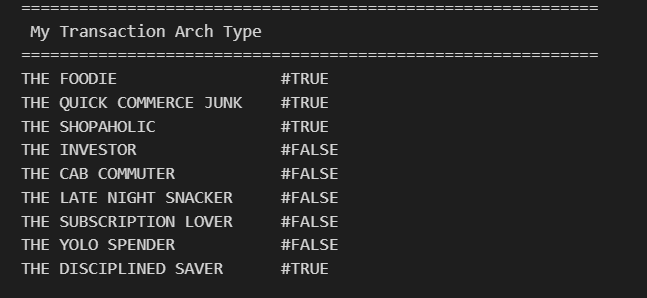